
# Nama: Sofyan Didik Asmara
# NIM: 4222311027
# Kelas: Robotika Malam A

# Assignment 6 Unsupervised Learning - KMeans Clustering Wine Quality Dataset


In [14]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



## Load Dataset

Dataset yang digunakan adalah Wine Quality Dataset yang diperoleh dari Kaggle.


In [15]:

df = pd.read_csv('WineQT.csv')

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



## Exploratory Data Analysis (EDA)


In [16]:

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None


In [17]:

print(df.describe())


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

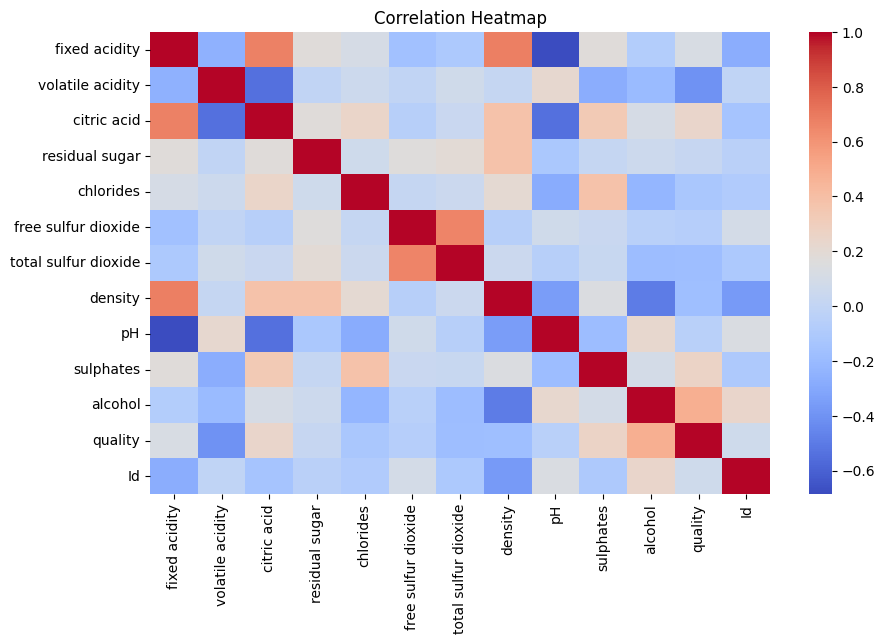

In [18]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


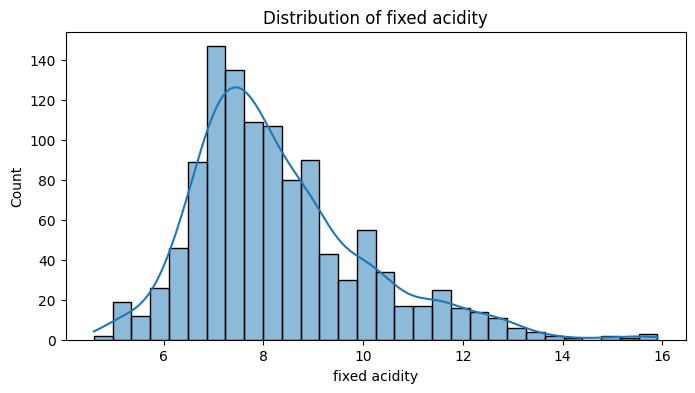

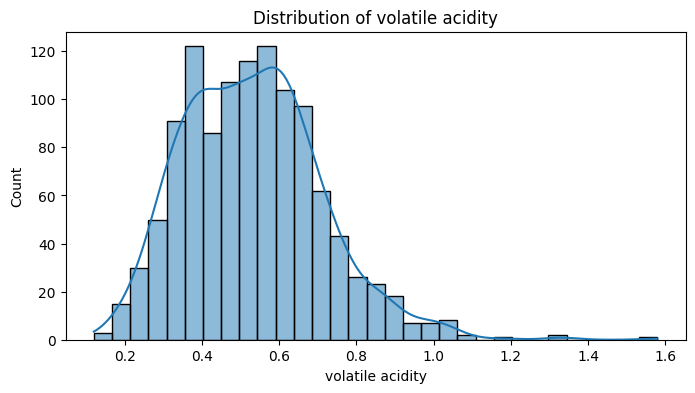

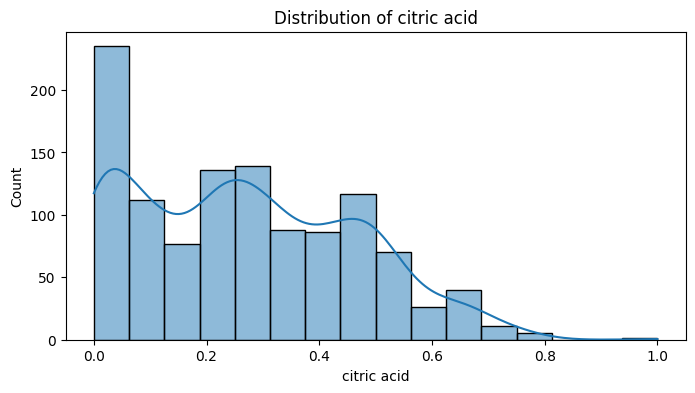

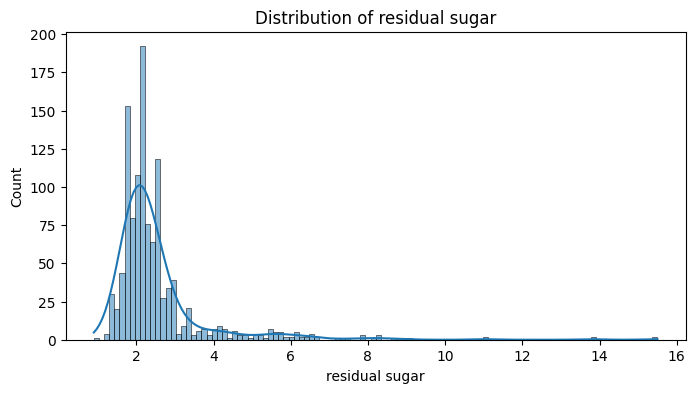

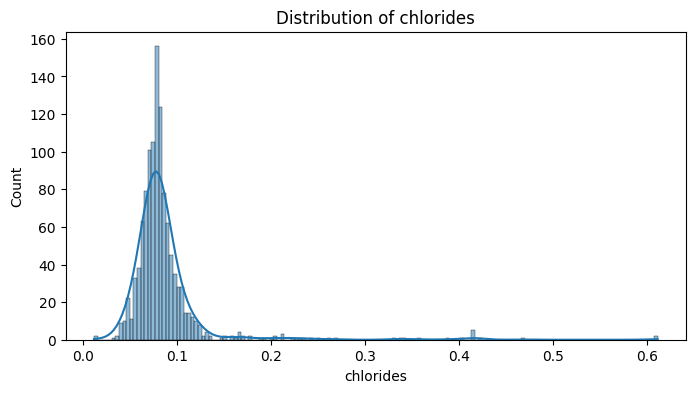

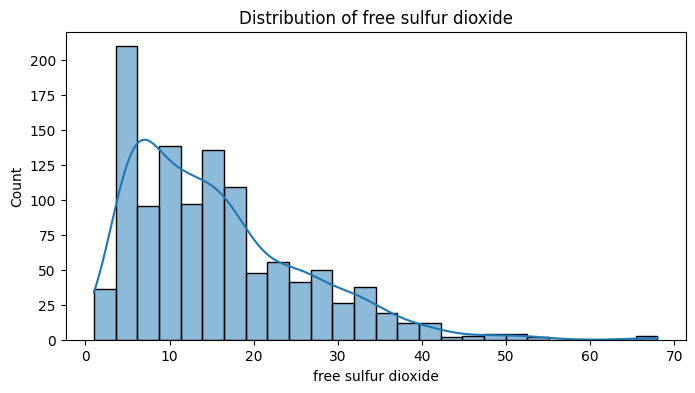

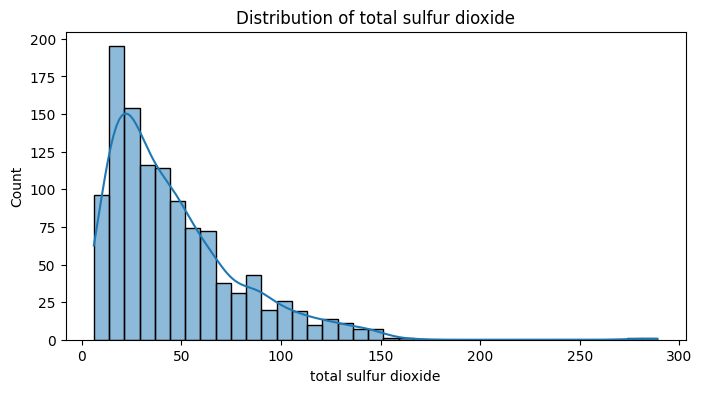

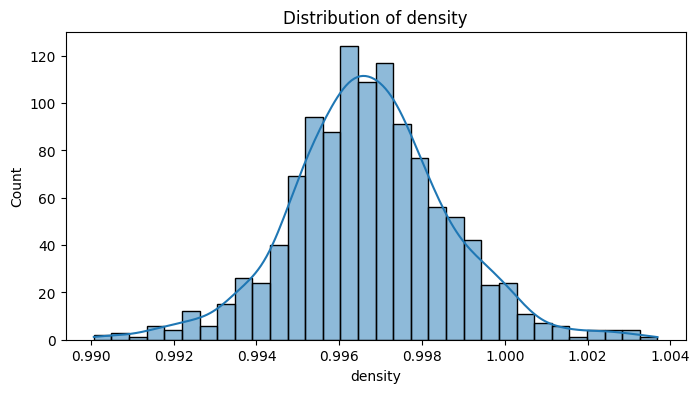

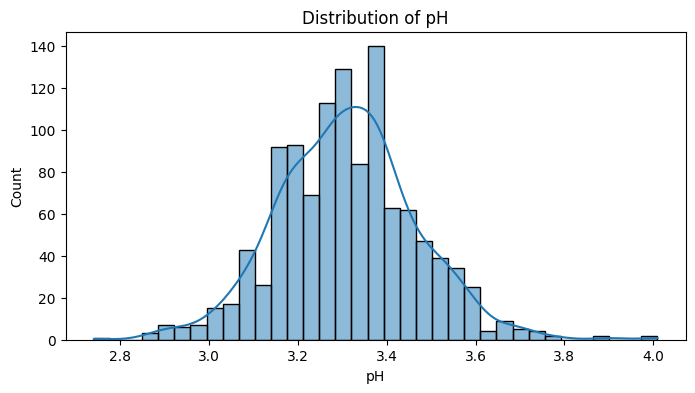

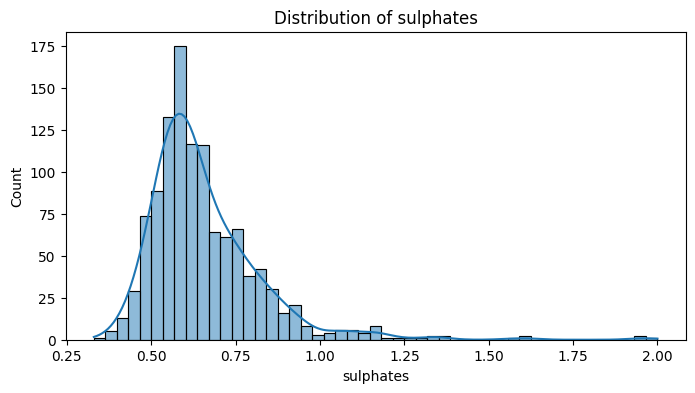

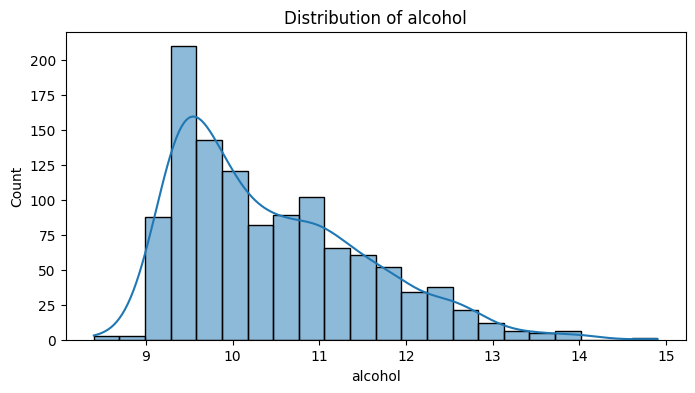

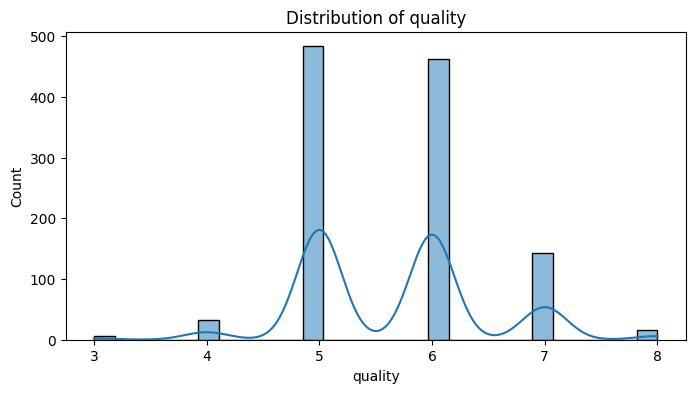

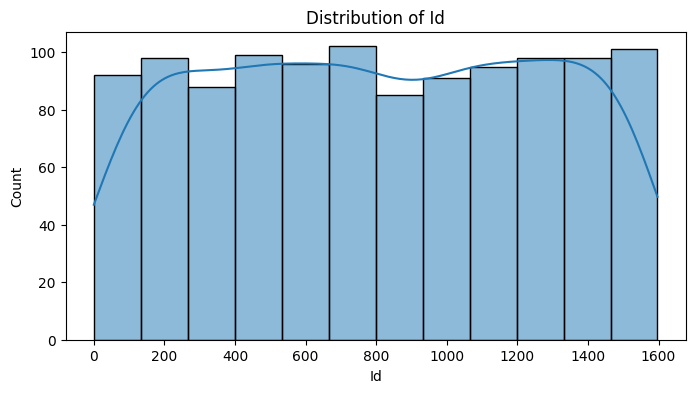

In [19]:

columns = df.columns

for col in columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()



## Feature Engineering

Pada tahap ini dilakukan preprocessing data sebelum digunakan pada model KMeans.


In [20]:

print(df.isnull().sum())


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [21]:

# Drop kolom Id karena tidak diperlukan
df = df.drop('Id', axis=1)

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [22]:

# Standarisasi data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)



## Menentukan Jumlah Cluster dengan Elbow Method


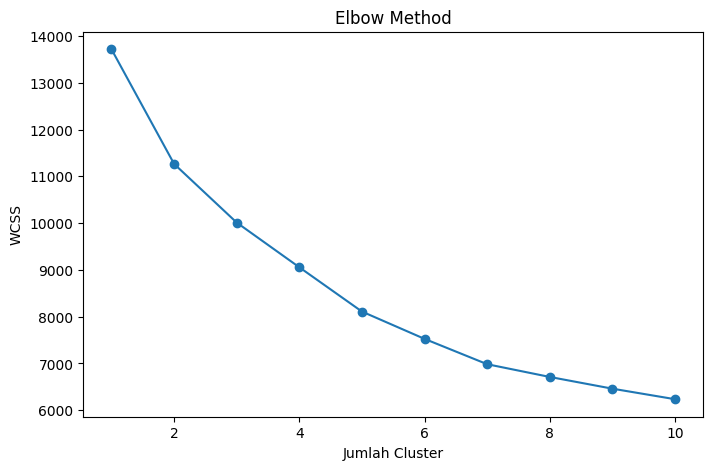

In [23]:

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()



Berdasarkan grafik elbow method, jumlah cluster yang digunakan adalah 3 cluster.



## Membuat Model KMeans


In [24]:

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1



## Visualisasi Cluster Menggunakan PCA


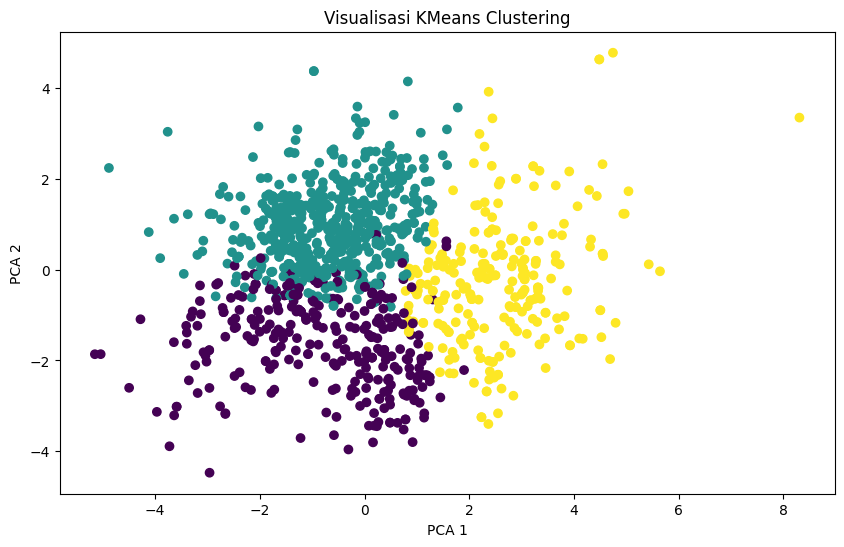

In [25]:

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(10,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters
)

plt.title('Visualisasi KMeans Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()


In [26]:

print(df['Cluster'].value_counts())


Cluster
1    592
0    301
2    250
Name: count, dtype: int64



## Kesimpulan

KMeans Clustering digunakan untuk mengelompokkan data wine berdasarkan karakteristik yang dimiliki. 
Sebelum proses clustering dilakukan, data dinormalisasi menggunakan StandardScaler agar setiap fitur memiliki skala yang sama.

Jumlah cluster ditentukan menggunakan metode elbow dengan melihat nilai WCSS. 
Hasil clustering menunjukkan bahwa data wine dapat dikelompokkan menjadi beberapa kelompok berdasarkan kemiripan karakteristik kimia wine.

Visualisasi menggunakan PCA membantu melihat persebaran cluster secara lebih jelas.
